# Run NMF on L23 $R_{\rm rs}$

In [1]:
# imports
# imports
from importlib import reload
from importlib.resources import files
import os
import numpy as np

from scipy.optimize import curve_fit

import pandas
import seaborn as sns
from matplotlib import pyplot as plt

from scipy.interpolate import interp1d

from oceancolor.hydrolight import loisel23
from oceancolor.utils import plotting as oc_plotting

from cnmf.oceanography import utils as co_utils
from cnmf import nmf_imaging

# Load L23

In [2]:
l23 = loisel23.load_ds(4,0)

## Unpack for convenience

In [3]:
l23_wave = l23.Lambda.data
l23_Rrs = l23.Rrs.data

In [4]:
l23_Rrs.shape

(3320, 81)

# NMF me

## Prep

### Scale by 1e4 for convenience

In [5]:
scaled_Rrs = l23_Rrs * 1e4

In [9]:
scaled_Rrs

array([[1.1761000e+02, 1.2011000e+02, 1.2205000e+02, ..., 1.2980001e-01,
        1.2384000e-01, 1.2053000e-01],
       [1.4809999e+02, 1.5098000e+02, 1.5242000e+02, ..., 1.5533000e-01,
        1.4873999e-01, 1.4502001e-01],
       [8.8531998e+01, 8.9675995e+01, 9.0611000e+01, ..., 1.2654001e-01,
        1.2081999e-01, 1.1772000e-01],
       ...,
       [8.0909996e+01, 8.2309998e+01, 8.3191002e+01, ..., 1.5196000e-01,
        1.4555000e-01, 1.4201000e-01],
       [4.9206001e+01, 5.0833000e+01, 5.2078999e+01, ..., 1.7808001e-01,
        1.7126000e-01, 1.6741000e-01],
       [4.9708000e+01, 5.1451000e+01, 5.2934002e+01, ..., 3.1913000e-01,
        3.0930001e-01, 3.0408001e-01]], dtype=float32)

In [15]:
new_spec, mask, err = co_utils.prep(scaled_Rrs, sigma=0.1)

## Do it

In [13]:
N_NMF = 4
outroot = 'L23_scaledRrs'
normalize = True
#
comps = nmf_imaging.NMFcomponents(
    ref=new_spec, mask=mask, ref_err=err,
    n_components=N_NMF,
    path_save=outroot, oneByOne=True,
    normalize=normalize,
    seed=12345)

Building components one by one...
	 path_save provided, you might want to load data and continue previous component calculation
		 loading from L23_scaledRrs_comp.npy for components.
		 L23_scaledRrs_comp.npy does not exist, calculating from scratch.
	1 of 4
Took 0.002 minutes to reach current solution.
			 Calculation for 1 components done, overwriting raw 2D component matrix at L23_scaledRrs_comp.npy
			 Calculation for 1 components done, overwriting raw 2D coefficient matrix at L23_scaledRrs_coef.npy
	2 of 4
Took 0.000 minutes to reach current solution.
			 Calculation for 2 components done, overwriting raw 2D component matrix at L23_scaledRrs_comp.npy
			 Calculation for 2 components done, overwriting raw 2D coefficient matrix at L23_scaledRrs_coef.npy
	3 of 4
Took 0.001 minutes to reach current solution.
			 Calculation for 3 components done, overwriting raw 2D component matrix at L23_scaledRrs_comp.npy
			 Calculation for 3 components done, overwriting raw 2D coefficient matrix a

/home/xavier/Projects/Oceanography/python/cnmf/cnmf/nmf_imaging.py:377: RuntimeWarning: invalid value encountered in divide
  components = (components.T/np.sqrt(np.nansum(components**2, axis = (1, 2))).T).T


# Load

In [16]:
M = np.load(outroot+'_comp.npy').T
coeff = np.load(outroot+'_coef.npy').T

# Plot

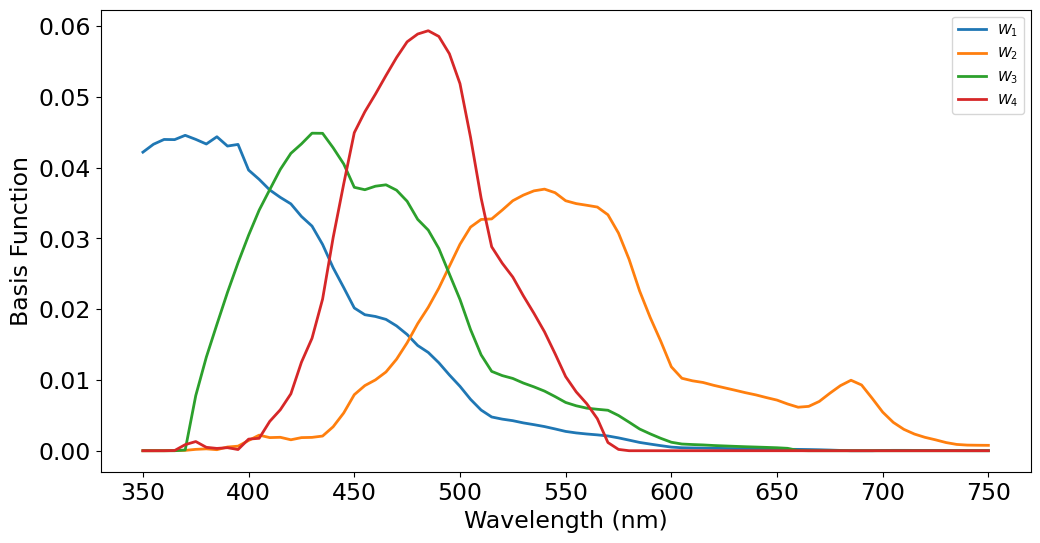

In [23]:
fig = plt.figure(figsize=(12,6))
ax = plt.gca()
#
for ii in range(N_NMF):
    # Step plot
    sns.lineplot(x=l23_wave, y=M[ii],
                 label=r'$W_'+f'{ii+1}'+'$',
                 ax=ax, lw=2)#
# Pretty me up
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Basis Function')
oc_plotting.set_fontsize(ax, 17.)
#
plt.show()